# Dirac Curvature vs Drive Amplitude

This notebook scans the circular-drive amplitude for the built-in driven Dirac model and compares three Berry-curvature quantities at $k=(0,0)$: the static curvature, the time-averaged Floquet curvature, and the time-averaged perturbed-state curvature.


## Imports and Shared Parameters

We begin by importing the Floquet toolkit pieces and defining one common set of physical and Floquet truncation parameters. The drive amplitude will be varied later while the frequency is kept fixed.


In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "floquet_toolkit").exists() and (repo_root.parent / "floquet_toolkit").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np

from floquet_toolkit import DiracModel, DiracParameters, FloquetLocalManager, UnitConvention
from floquet_toolkit.config import (
    DriveParameters,
    FloquetParameters,
    MEV_TO_J,
)

SI_UNITS = UnitConvention.SI_UNITS()
DEFAULT_DIRAC_PARAMS = DiracParameters(
    units=SI_UNITS,
    vf=1.0e6,
    mass=-40.0 * MEV_TO_J,
)
DEFAULT_FLOQUET_PARAMS = FloquetParameters(
    n_harmonics=3,
    n_trunc=15,
    n_time=31,
)


## Curvature Scan Helper

The helper below varies the right-circular drive amplitude, evaluates all three curvature definitions at $k=(0,0)$, and stores the time-averaged Floquet and perturbed-state values.

In [2]:
def compute_time_averaged_curvature_vs_drive_amplitude(
    amplitudes: np.ndarray,
    dk: float = 1.0e4,
):
    static_curvature_results = []
    floquet_curvature_results = []
    perturbed_curvature_results = []

    for amplitude in amplitudes:
        drive_params = DriveParameters(
            units=SI_UNITS,
            AL=0.0,
            AR=float(amplitude),
        )
        model = DiracModel(DEFAULT_DIRAC_PARAMS, drive_params).to_driven_hamiltonian()
        manager = FloquetLocalManager(model, DEFAULT_FLOQUET_PARAMS)
        time_grid = np.linspace(0.0, drive_params.period, DEFAULT_FLOQUET_PARAMS.n_time, endpoint=False)

        floquet_curvature = manager.compute_instantaneous_berry_curvature(
            time=time_grid,
            kx=0.0,
            ky=0.0,
            band="conduction",
            dk=dk,
        )
        perturbed_curvature = manager.compute_perturbed_state_berry_curvature(
            time=time_grid,
            kx=0.0,
            ky=0.0,
            band="conduction",
            dk=dk,
        )
        static_curvature = manager.compute_static_berry_curvature(
            kx=0.0,
            ky=0.0,
            band="conduction",
            dk=dk,
        )

        floquet_curvature_results.append(float(np.mean(floquet_curvature)))
        perturbed_curvature_results.append(float(np.mean(perturbed_curvature)))
        static_curvature_results.append(float(static_curvature))

    return (
        np.asarray(static_curvature_results),
        np.asarray(floquet_curvature_results),
        np.asarray(perturbed_curvature_results),
    )


## Plot the Amplitude Dependence

We now generate the scan and plot the three curvature curves against the circular-drive amplitude.


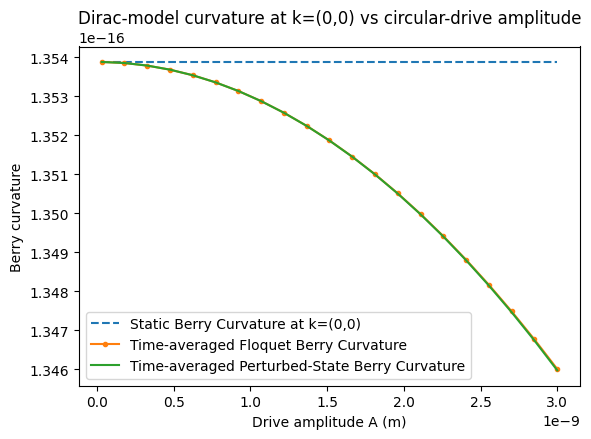

In [3]:
amplitudes = np.linspace(0.03e-9, 3.0e-9, 21)
static_curvature, floquet_curvature, perturbed_curvature = (
    compute_time_averaged_curvature_vs_drive_amplitude(amplitudes, dk=1.0e4)
)

plt.figure(figsize=(6, 4.5))
plt.plot(amplitudes, static_curvature, "--", label="Static Berry Curvature at k=(0,0)")
plt.plot(amplitudes, floquet_curvature, ".-", label="Time-averaged Floquet Berry Curvature")
plt.plot(amplitudes, perturbed_curvature, label="Time-averaged Perturbed-State Berry Curvature")
plt.xlabel("Drive amplitude A (m)")
plt.ylabel("Berry curvature")
plt.title("Dirac-model curvature at k=(0,0) vs circular-drive amplitude")
plt.legend()
plt.tight_layout()
plt.show()
